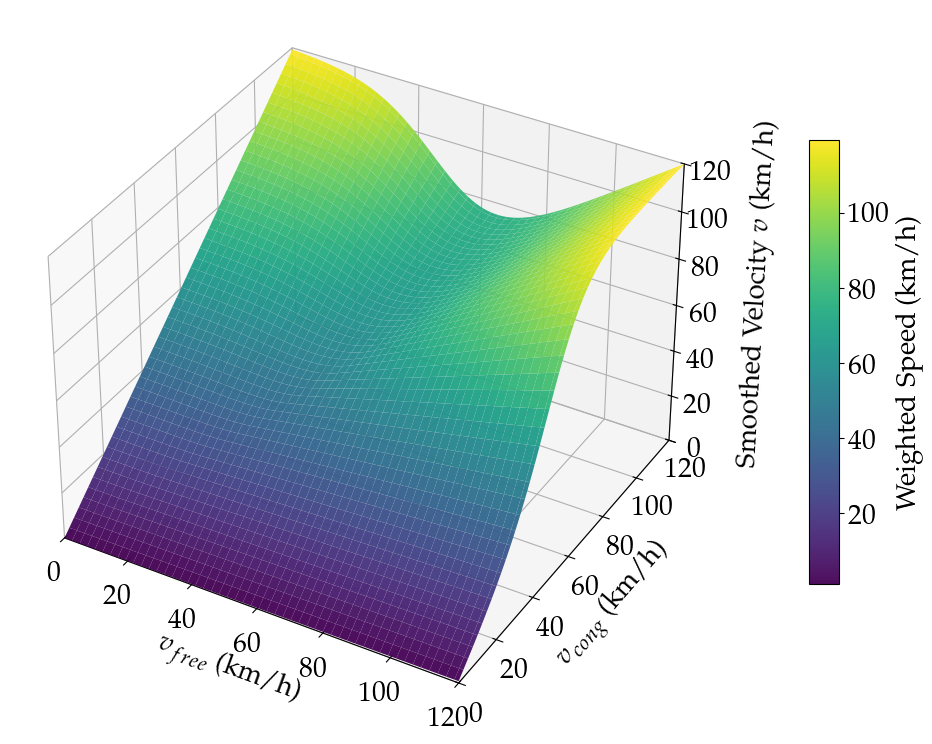

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Palatino']
# use 22 pt font size for all text
plt.rcParams['font.size'] = 20
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# 1. Define the grid in km/h
# Range 0 to 120 km/h covers typical highway speeds
v_free = np.linspace(0, 120, 100)
v_cong = np.linspace(0, 120, 100)
V_free, V_cong = np.meshgrid(v_free, v_cong)

# 2. Define Adaptive Smoothing parameters in km/h
# V_c: Critical velocity (transition from free-flow to congested)
# dV: Transition width
V_c = 50.0  # km/h
dV = 20.0   # km/h

# 3. Calculate the weight 'w'
# w depends on the minimum velocity to detect congestion from either direction
V_min = np.minimum(V_free, V_cong)
w = 0.5 * (1 + np.tanh((V_c - V_min) / dV))

# 4. Calculate the resulting smoothed velocity Z (in km/h)
Z = w * V_cong + (1 - w) * V_free

# 5. Create the 3D Surface Plot
fig = plt.figure(figsize=(10, 8), dpi=100)
ax = fig.add_subplot(111, projection='3d')

# Plot surface
surf = ax.plot_surface(V_free, V_cong, Z, cmap='viridis', 
                       edgecolor='none', alpha=0.95, antialiased=True)

# 6. Formatting with km/h labels
ax.set_xlabel(r'$v_{free}$ (km/h)', fontsize=20, labelpad=10)
ax.set_ylabel(r'$v_{cong}$ (km/h)', fontsize=20, labelpad=10)

# Z-axis label
ax.set_zlabel(r'Smoothed Velocity $v$ (km/h)', 
              fontsize=20, labelpad=15, rotation=90)

# Set axis limits to match typical highway speeds
ax.set_xlim(0, 120)
ax.set_ylim(0, 120)
ax.set_zlim(0, 120)

# Add the colorbar
cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=15, pad=0.1)
cbar.set_label(r'Weighted Speed (km/h)', fontsize=20)

# Adjust view angle to match the reference image
ax.view_init(elev=35, azim=-60)

plt.tight_layout()
plt.savefig('../figures/appendix/adaptive_smoothing_velocity_kmh.pdf', 
            dpi=300, bbox_inches='tight')
plt.show()

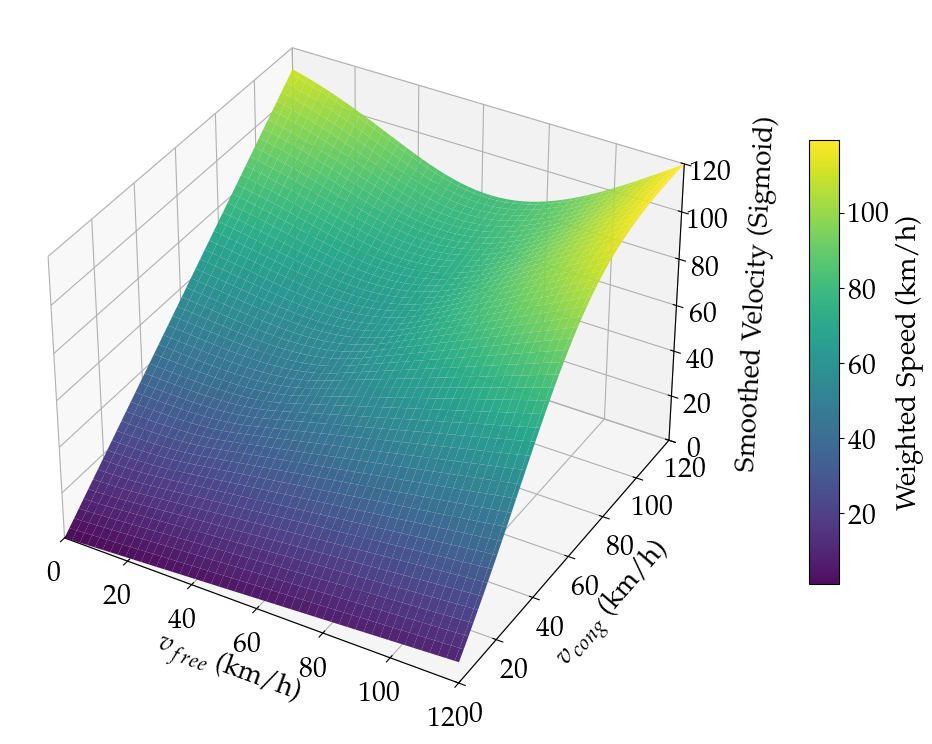

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the grid in km/h
v_free = np.linspace(0, 120, 100)
v_cong = np.linspace(0, 120, 100)
V_free, V_cong = np.meshgrid(v_free, v_cong)

# 2. Parameters
V_c = 50.0  # Critical velocity (km/h)
dV = 20.0   # Transition width

# 3. Calculate 'w' using the SIGMOID function
# We want w ~ 1 when v is low (congestion)
# We want w ~ 0 when v is high (free flow)
V_min = np.minimum(V_free, V_cong)

# Note: The negative sign inside exp() is handled by the order of subtraction (V_c - V_min).
# If V_min < V_c (Congested): (V_c - V_min) is positive -> exp(-large) -> w approaches 1
# If V_min > V_c (Free Flow): (V_c - V_min) is negative -> exp(large)  -> w approaches 0
w = 1 / (1 + np.exp(-(V_c - V_min) / dV))

# 4. Calculate Z
Z = w * V_cong + (1 - w) * V_free

# 5. Plotting
fig = plt.figure(figsize=(10, 8), dpi=100)
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(V_free, V_cong, Z, cmap='viridis', 
                       edgecolor='none', alpha=0.95, antialiased=True)

ax.set_xlabel(r'$v_{free}$ (km/h)', fontsize=20, labelpad=10)
ax.set_ylabel(r'$v_{cong}$ (km/h)', fontsize=20, labelpad=10)
ax.set_zlabel(r'Smoothed Velocity (Sigmoid)', fontsize=20, labelpad=15, rotation=90)
# ax.set_title('ASM Weighting using Sigmoid Function', fontsize=14)

ax.set_xlim(0, 120)
ax.set_ylim(0, 120)
ax.set_zlim(0, 120)

cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=15, pad=0.1)
cbar.set_label(r'Weighted Speed (km/h)', fontsize=20)

ax.view_init(elev=35, azim=-60)
plt.tight_layout()
plt.savefig('../figures/appendix/adaptive_smoothing_velocity_sigmoid.pdf', 
            dpi=300, bbox_inches='tight')
plt.show()

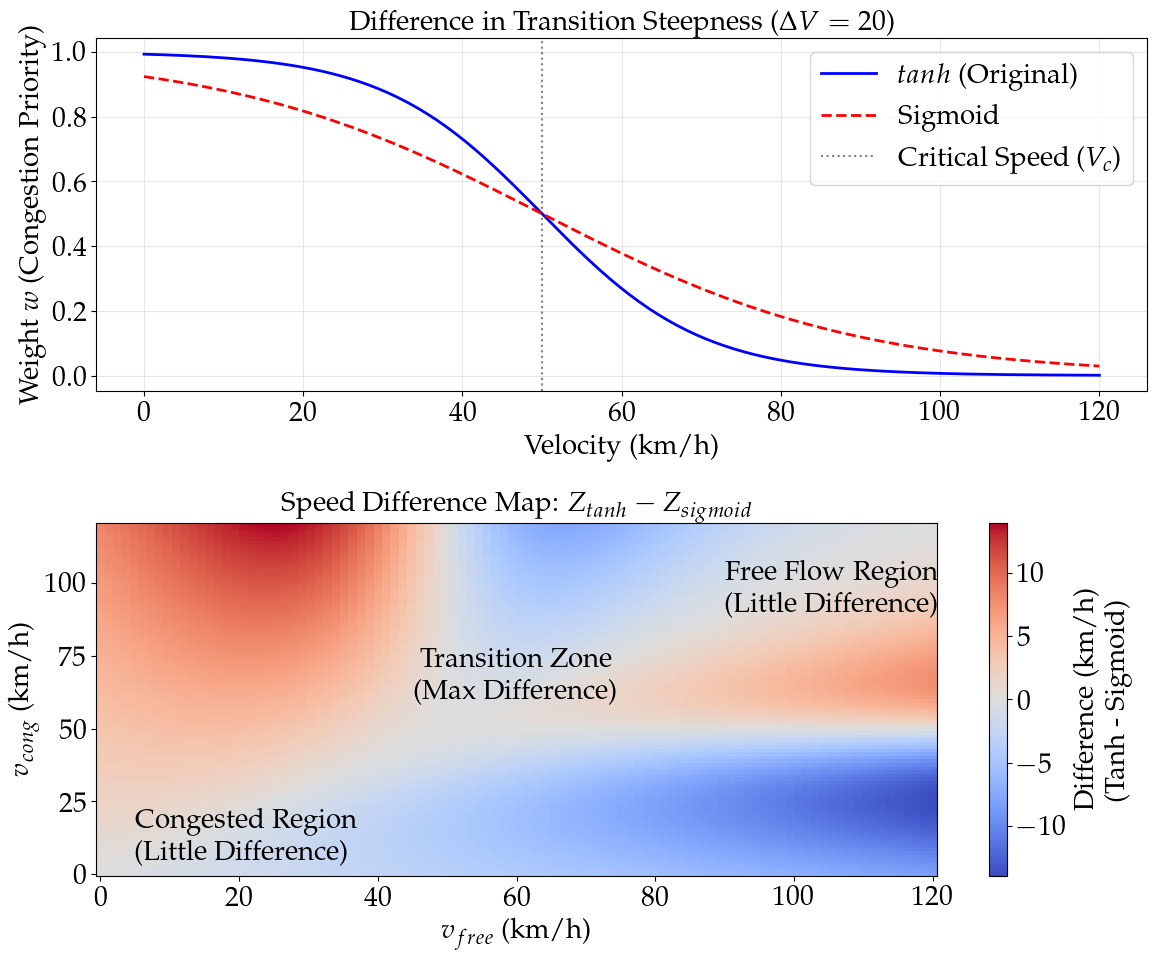

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Data
v = np.linspace(0, 120, 200)
v_free = np.linspace(0, 120, 100)
v_cong = np.linspace(0, 120, 100)
V_free, V_cong = np.meshgrid(v_free, v_cong)
V_min = np.minimum(V_free, V_cong)

# Parameters
V_c = 50.0
dV = 20.0

# 2. Calculate Weights (1D for cross-section)
# We look at the transition where v_free = v_cong = v
w_tanh_1d = 0.5 * (1 + np.tanh((V_c - v) / dV))
w_sig_1d  = 1 / (1 + np.exp(-(V_c - v) / dV))

# 3. Calculate 3D Surfaces
W_tanh = 0.5 * (1 + np.tanh((V_c - V_min) / dV))
W_sig  = 1 / (1 + np.exp(-(V_c - V_min) / dV))

Z_tanh = W_tanh * V_cong + (1 - W_tanh) * V_free
Z_sig  = W_sig * V_cong + (1 - W_sig) * V_free

# Calculate the difference matrix (in km/h)
Difference = Z_tanh - Z_sig

# 4. Plotting
fig = plt.figure(figsize=(12, 10))

# --- Plot 1: The Transition Shape (Weight vs Speed) ---
ax1 = fig.add_subplot(2, 1, 1)
ax1.plot(v, w_tanh_1d, 'b-', linewidth=2, label='$tanh$ (Original)')
ax1.plot(v, w_sig_1d, 'r--', linewidth=2, label='Sigmoid')
ax1.axvline(V_c, color='k', linestyle=':', alpha=0.5, label='Critical Speed ($V_c$)')
ax1.set_title(r'Difference in Transition Steepness ($\Delta V=20$)', fontsize=20)
ax1.set_xlabel('Velocity (km/h)', fontsize=20)
ax1.set_ylabel('Weight $w$ (Congestion Priority)', fontsize=20)
ax1.legend(fontsize=20)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Heatmap of the Difference ---
ax2 = fig.add_subplot(2, 1, 2)
# We plot the absolute difference to show magnitude
c = ax2.pcolormesh(V_free, V_cong, Difference, cmap='coolwarm', shading='auto')
cbar = fig.colorbar(c, ax=ax2)
cbar.set_label('Difference (km/h)\n(Tanh - Sigmoid)', fontsize=20)

ax2.set_title(r'Speed Difference Map: $Z_{tanh} - Z_{sigmoid}$', fontsize=20)
ax2.set_xlabel(r'$v_{free}$ (km/h)', fontsize=20)
ax2.set_ylabel(r'$v_{cong}$ (km/h)', fontsize=20)
ax2.text(5, 5, 'Congested Region\n(Little Difference)', color='black')
ax2.text(90, 90, 'Free Flow Region\n(Little Difference)', color='black')
ax2.text(60, 60, 'Transition Zone\n(Max Difference)', color='black', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/appendix/adaptive_smoothing_difference_tanh_sigmoid.pdf', 
            dpi=300, bbox_inches='tight')
plt.show()